#real data

Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\boxplot_grid_all_topics_euclidean_min.png


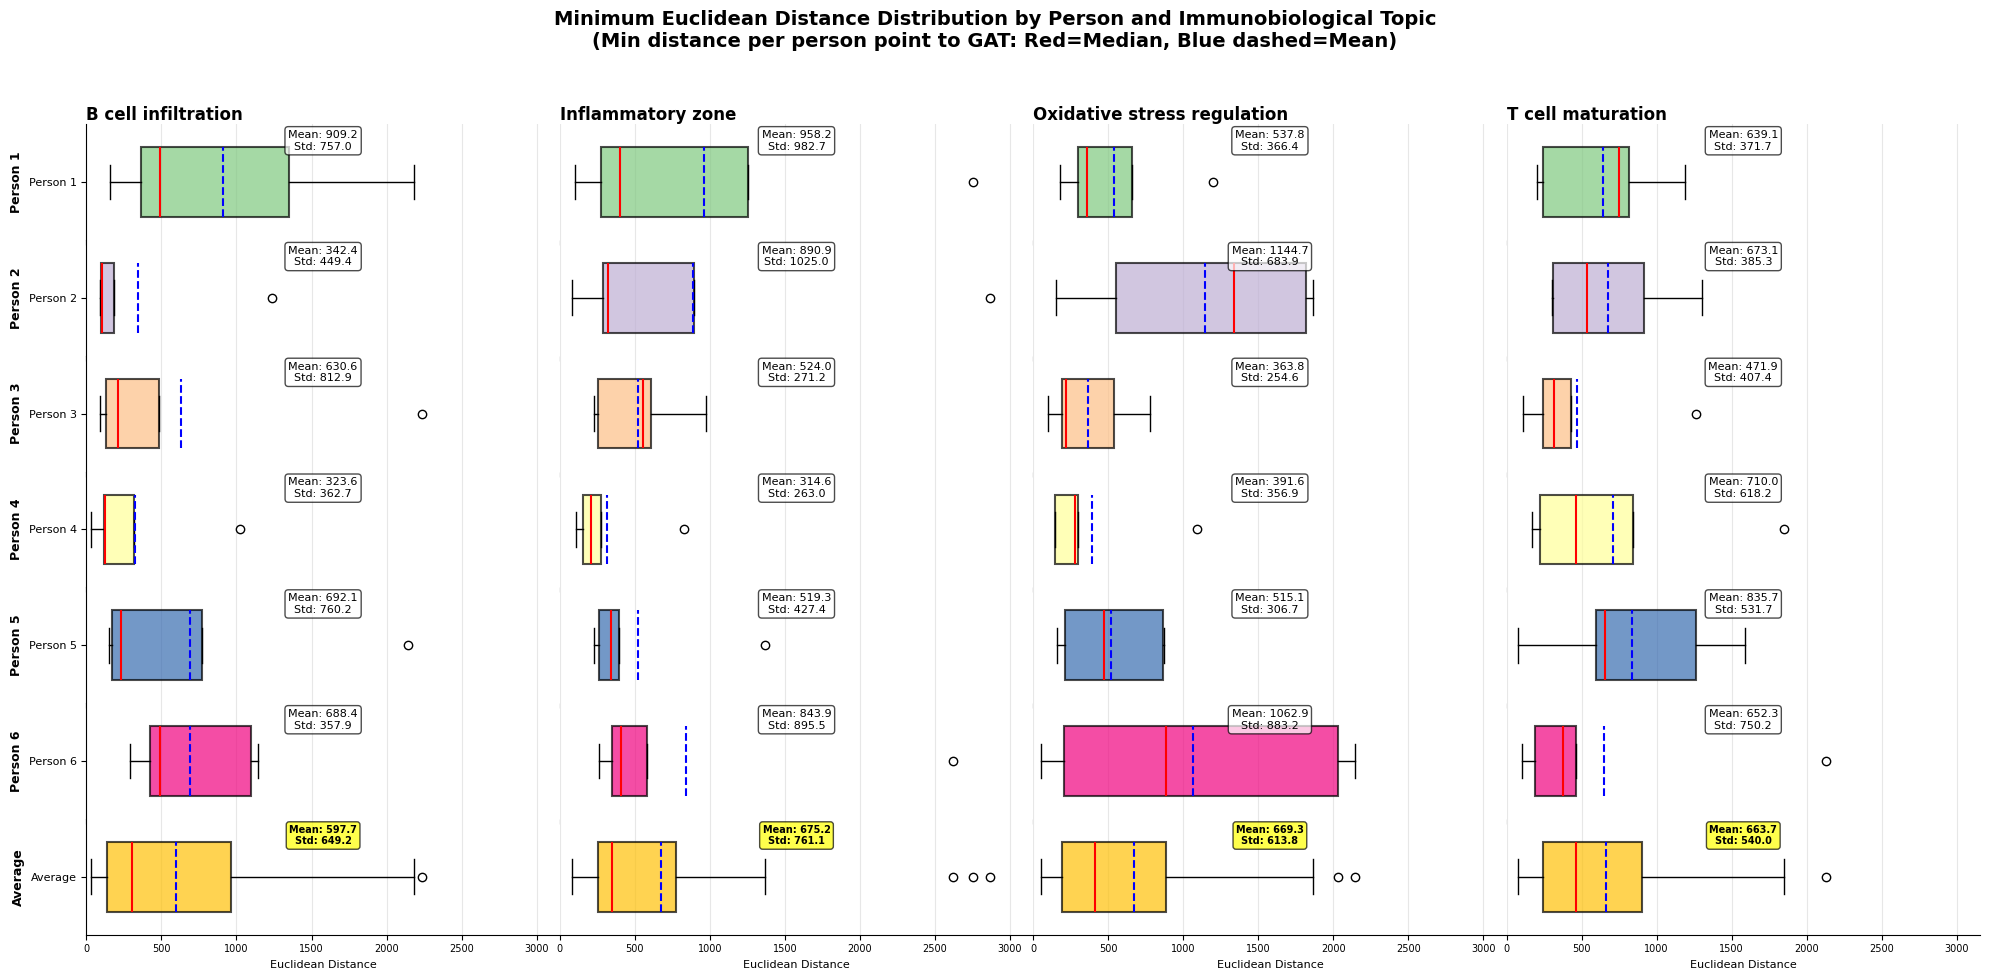

Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\heatmap_euclidean_distance_min.png


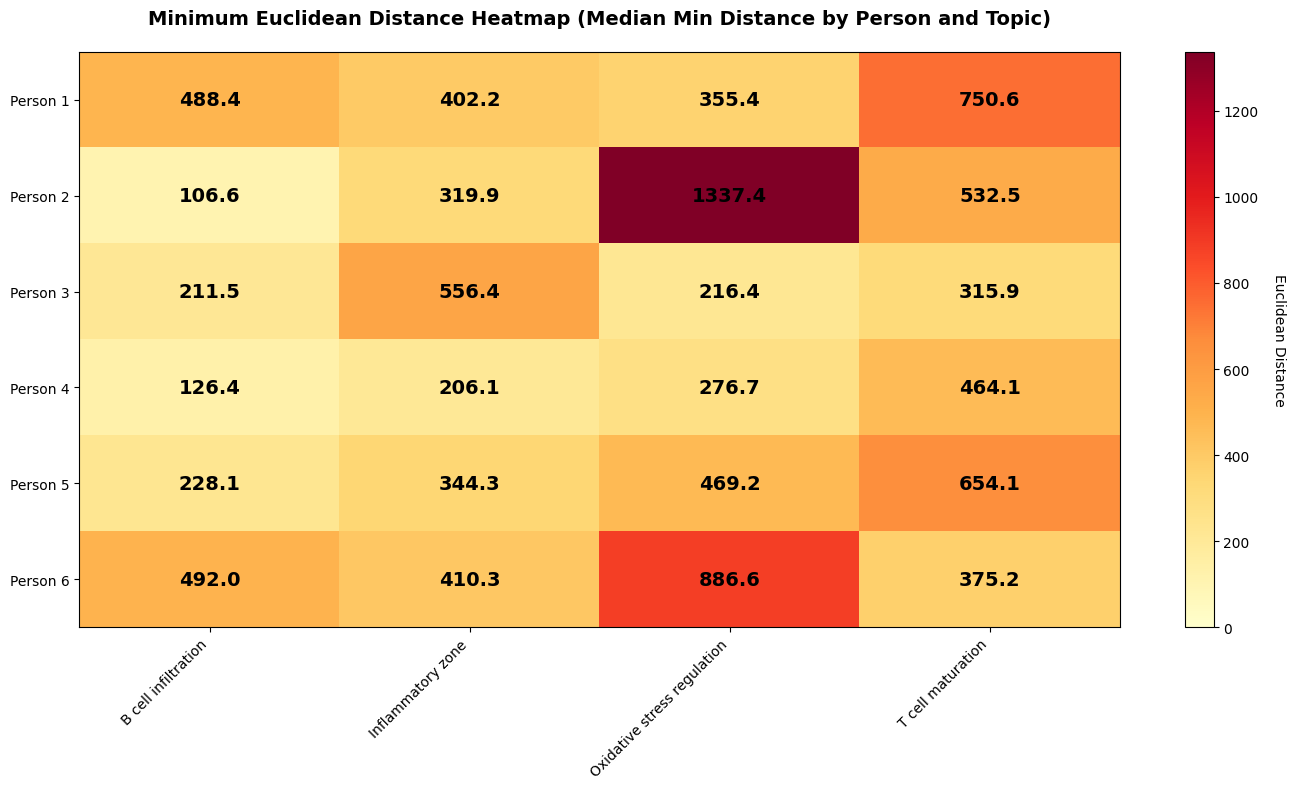

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

def euclidean_distance_3d(p1, p2):
    """Calculate 3D Euclidean distance between two points"""
    return math.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2 + (p2[2] - p1[2])**2)

def calc_min_euclidean_distances(gat_data, person_data):
    """For each person point, find minimum distance to any GAT point"""
    if len(gat_data) == 0 or len(person_data) == 0: 
        return []
    
    gat_points = [(row['x'], row['y'], row['z']) for _, row in gat_data.iterrows()]
    min_distances = []
    
    for _, person_row in person_data.iterrows():
        person_point = (person_row['x'], person_row['y'], person_row['z'])
        distances = [euclidean_distance_3d(person_point, gat_point) for gat_point in gat_points]
        min_distances.append(min(distances))
    
    return min_distances

# Process CSV files
results = {}
all_distances = {f'Person {i}': [] for i in range(1, 7)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy().sort_values(by='ROI_ID').reset_index(drop=True)
    results[sheet_name] = {}
    
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy().sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            continue
        
        distances = calc_min_euclidean_distances(gat_data, person_data)
        
        if len(distances) > 0:
            results[sheet_name][person_name] = {
                'distances': distances,
                'mean': np.mean(distances),
                'median': np.median(distances),
                'std': np.std(distances),
                'min': np.min(distances),
                'max': np.max(distances)
            }
            all_distances[person_name].extend(distances)


person_names = [f'Person {i}' for i in range(1, 7)]
person_colors = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#f0027f']
topics_list = list(results.keys())

# Calculate max distance for x-axis limits
max_distance = 0
for sheet_name in topics_list:
    for person_name in person_names:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
            max_distance = max(max_distance, results[sheet_name][person_name]['max'])
x_max = max_distance * 1.1 if max_distance > 0 else 1000

if len(topics_list) > 0:
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(7, 4, hspace=0.0, wspace=0.0)

    for col_idx, sheet_name in enumerate(topics_list):
        all_topic_distances = []
        
        for row_idx, person_name in enumerate(person_names):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            if person_name in results[sheet_name]:
                distances = results[sheet_name][person_name]['distances']
                if len(distances) > 0:
                    all_topic_distances.extend(distances)
                    bp = ax.boxplot([distances], tick_labels=[person_name], patch_artist=True,
                                   vert=False, showmeans=True, meanline=True,
                                   boxprops=dict(linewidth=1.5),
                                   medianprops=dict(linewidth=1.5, color='red'),
                                   meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                                   whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
                    bp['boxes'][0].set_facecolor(person_colors[row_idx])
                    bp['boxes'][0].set_alpha(0.7)
                    bp['boxes'][0].set_edgecolor('black')
                    bp['boxes'][0].set_linewidth(1.5)
                    
                    stats = results[sheet_name][person_name]
                    stats_text = f"Mean: {stats['mean']:.1f}\nStd: {stats['std']:.1f}"
                    ax.text(0.5, 0.95, stats_text, transform=ax.transAxes,
                           ha='center', va='top', fontsize=8,
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                else:
                    bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
                    bp['boxes'][0].set_facecolor('lightgray')
                    bp['boxes'][0].set_alpha(0.3)
            else:
                bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
                bp['boxes'][0].set_facecolor('lightgray')
                bp['boxes'][0].set_alpha(0.3)
            
            ax.set_xlim(0, x_max)
            ax.grid(True, alpha=0.3, axis='x')
            ax.tick_params(axis='y', labelsize=8)
            ax.tick_params(axis='x', labelsize=7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if row_idx < 6:
                ax.spines['bottom'].set_visible(False)
            if col_idx > 0:
                ax.spines['left'].set_visible(False)
            
            if col_idx == 0:
                ax.set_ylabel(person_name, fontsize=9, fontweight='bold')
            else:
                ax.set_ylabel('')
                ax.set_yticks([])
            
            if row_idx == 6:
                ax.set_xlabel('Euclidean Distance', fontsize=8)
            else:
                ax.set_xticklabels([])
            
            if row_idx == 0:
                full_name = sheet_name.replace('_', ' ').replace('-', ' ')
                ax.set_title(full_name, fontsize=12, fontweight='bold', pad=3, ha='left', x=0)
        
        ax_avg = fig.add_subplot(gs[6, col_idx])
        if len(all_topic_distances) > 0:
            bp_avg = ax_avg.boxplot([all_topic_distances], tick_labels=['Average'], patch_artist=True,
                                   vert=False, showmeans=True, meanline=True,
                                   boxprops=dict(linewidth=1.5),
                                   medianprops=dict(linewidth=1.5, color='red'),
                                   meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                                   whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
            bp_avg['boxes'][0].set_facecolor('#FFC107')
            bp_avg['boxes'][0].set_alpha(0.7)
            bp_avg['boxes'][0].set_edgecolor('black')
            bp_avg['boxes'][0].set_linewidth(1.5)
            
            stats_text = f"Mean: {np.mean(all_topic_distances):.1f}\nStd: {np.std(all_topic_distances):.1f}"
            ax_avg.text(0.5, 0.95, stats_text, transform=ax_avg.transAxes,
                       ha='center', va='top', fontsize=7, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        else:
            bp_avg = ax_avg.boxplot([[]], tick_labels=['Average'], patch_artist=True, vert=False, widths=0.6)
            bp_avg['boxes'][0].set_facecolor('lightgray')
            bp_avg['boxes'][0].set_alpha(0.3)
        
        ax_avg.set_xlim(0, x_max)
        ax_avg.grid(True, alpha=0.3, axis='x')
        ax_avg.tick_params(axis='y', labelsize=8)
        ax_avg.tick_params(axis='x', labelsize=7)
        ax_avg.set_xlabel('Euclidean Distance', fontsize=8)
        ax_avg.spines['top'].set_visible(False)
        ax_avg.spines['right'].set_visible(False)
        if col_idx > 0:
            ax_avg.spines['left'].set_visible(False)
        
        if col_idx == 0:
            ax_avg.set_ylabel('Average', fontsize=9, fontweight='bold')
        else:
            ax_avg.set_ylabel('')
            ax_avg.set_yticks([])

    fig.suptitle('Minimum Euclidean Distance Distribution by Person and Immunobiological Topic\n(Min distance per person point to GAT: Red=Median, Blue dashed=Mean)', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    output_path = base_dir / 'boxplot_grid_all_topics_euclidean_min.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.show()

    # Create heatmap
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    heatmap_data = []
    heatmap_rows = []
    
    for person_name in person_names:
        row_data = []
        for sheet_name in topics_list:
            if person_name in results[sheet_name] and len(results[sheet_name][person_name]['distances']) > 0:
                row_data.append(results[sheet_name][person_name]['median'])
            else:
                row_data.append(np.nan)
        if any(not np.isnan(x) for x in row_data):
            heatmap_data.append(row_data)
            heatmap_rows.append(person_name)
    
    if len(heatmap_data) > 0:
        heatmap_array = np.array(heatmap_data)
        vmax = np.nanmax(heatmap_array) if np.nanmax(heatmap_array) > 0 else 1000
        im = ax2.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)
        
        ax2.set_xticks(np.arange(len(topics_list)))
        ax2.set_yticks(np.arange(len(heatmap_rows)))
        ax2.set_xticklabels([name.replace('_', ' ').replace('-', ' ') for name in topics_list], rotation=45, ha='right')
        ax2.set_yticklabels(heatmap_rows)
        
        for i in range(len(heatmap_rows)):
            for j in range(len(topics_list)):
                if not np.isnan(heatmap_array[i, j]):
                    ax2.text(j, i, f'{heatmap_array[i, j]:.1f}', ha="center", va="center", 
                            color="black", fontsize=14, fontweight='bold')
        
        ax2.set_title('Minimum Euclidean Distance Heatmap (Median Min Distance by Person and Topic)', 
                     fontsize=14, fontweight='bold', pad=20)
        cbar = plt.colorbar(im, ax=ax2)
        cbar.set_label('Euclidean Distance', rotation=270, labelpad=20)
        
        plt.tight_layout()
        heatmap_path = base_dir / 'heatmap_euclidean_distance_min.png'
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {heatmap_path}")
        plt.show()


heatmap calculation for overlap in volumetric